# 🏀 Tutoriel appliqué — API NBA (`nba_api`)
## Contexte : Étude du momentum des équipes NBA

Ce notebook présente une introduction pratique à l'utilisation de la librairie Python `nba_api` pour extraire des données NBA, avec un focus particulier sur les données **play-by-play** (action par action), très utiles pour l'analyse du momentum des équipes.

---
### Plan
1. Installation & imports
2. Rechercher des équipes et des matchs
3. Récupérer le box score d'un match
4. 🔍 **Play-by-Play** : récupérer toutes les actions d'un match
5. Visualiser le momentum (score différentiel au fil du temps)


## 1. Imports

`nba_api` est organisée en deux grands modules :
- `nba_api.stats` → statistiques officielles NBA (matchs, joueurs, équipes, play-by-play…)
- `nba_api.live` → données en temps réel (scores en direct, play-by-play live)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time

from nba_api.stats.endpoints import (
    leaguegamefinder,
    boxscoretraditionalv2,
    playbyplayv3,
    teamgamelog,
)
from nba_api.stats.static import teams, players

SLEEP = 1.0

def nba_request_with_retry(endpoint_cls, max_retries: int = 4, backoff: float = 3.0, **kwargs):
    """Appelle un endpoint nba_api avec retry exponentiel."""
    delay = backoff
    for attempt in range(1, max_retries + 1):
        try:
            return endpoint_cls(timeout=60, **kwargs)
        except Exception as e:
            if attempt == max_retries:
                raise
            print(f"  ⚠️  Tentative {attempt}/{max_retries} échouée ({type(e).__name__}). "
                  f"Nouvelle tentative dans {delay:.0f}s…")
            time.sleep(delay)
            delay *= 2

print("✅ Imports OK")


✅ Imports OK


## 2. Référentiels statiques — Équipes & Joueurs

Les référentiels `teams` et `players` sont des listes statiques (pas de requête réseau) très utiles pour retrouver les IDs.


In [6]:
# Toutes les équipes NBA
all_teams = teams.get_teams()
df_teams = pd.DataFrame(all_teams)
print(f"Nombre d'équipes : {len(df_teams)}")
df_teams.head(10)


Nombre d'équipes : 30


,id,full_name,abbreviation,nickname,city,state,year_founded
0,1610612737,Atlanta Hawks,ATL,Hawks,Atlanta,Georgia,1949
1,1610612738,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946
2,1610612739,Cleveland Cavaliers,CLE,Cavaliers,Cleveland,Ohio,1970
3,1610612740,New Orleans Pelicans,NOP,Pelicans,New Orleans,Louisiana,2002
4,1610612741,Chicago Bulls,CHI,Bulls,Chicago,Illinois,1966
5,1610612742,Dallas Mavericks,DAL,Mavericks,Dallas,Texas,1980
6,1610612743,Denver Nuggets,DEN,Nuggets,Denver,Colorado,1976
7,1610612744,Golden State Warriors,GSW,Warriors,San Francisco,California,1946
8,1610612745,Houston Rockets,HOU,Rockets,Houston,Texas,1967
9,1610612746,Los Angeles Clippers,LAC,Clippers,Los Angeles,California,1970


In [7]:
# Trouver une équipe par son nom (fuzzy search)
def get_team_id(name: str) -> dict:
    result = teams.find_teams_by_full_name(name)
    if not result:
        result = teams.find_teams_by_nickname(name)
    if not result:
        raise ValueError(f"Équipe '{name}' introuvable.")
    return result[0]

gsw = get_team_id("Golden State Warriors")
bos = get_team_id("Boston Celtics")
print("Golden State Warriors :", gsw)
print("Boston Celtics        :", bos)


Golden State Warriors : {'id': 1610612744, 'full_name': 'Golden State Warriors', 'abbreviation': 'GSW', 'nickname': 'Warriors', 'city': 'San Francisco', 'state': 'California', 'year_founded': 1946}
Boston Celtics        : {'id': 1610612738, 'full_name': 'Boston Celtics', 'abbreviation': 'BOS', 'nickname': 'Celtics', 'city': 'Boston', 'state': 'Massachusetts', 'year_founded': 1946}


## 3. Récupérer les matchs d'une équipe — `LeagueGameFinder` & `TeamGameLog`

`LeagueGameFinder` permet de filtrer les matchs par équipe, saison, type de saison, etc.


In [8]:
SEASON = "2023-24"
TEAM_ID = gsw["id"]  # Golden State Warriors

gamelog = nba_request_with_retry(
    teamgamelog.TeamGameLog,
    team_id=TEAM_ID,
    season=SEASON,
    season_type_all_star="Regular Season",
)
time.sleep(SLEEP)

df_games = gamelog.get_data_frames()[0]
print(f"Matchs récupérés : {len(df_games)}")
df_games[["Game_ID", "GAME_DATE", "MATCHUP", "WL", "PTS"]].head(10)


Matchs récupérés : 82


,Game_ID,GAME_DATE,MATCHUP,WL,PTS
0,0022301198,"APR 14, 2024",GSW vs. UTA,W,123
1,0022301182,"APR 12, 2024",GSW vs. NOP,L,109
2,0022301169,"APR 11, 2024",GSW @ POR,W,100
3,0022301155,"APR 09, 2024",GSW @ LAL,W,134
4,0022301142,"APR 07, 2024",GSW vs. UTA,W,118
5,0022301097,"APR 05, 2024",GSW @ DAL,L,106
6,0022301113,"APR 04, 2024",GSW @ HOU,W,133
7,0022300589,"APR 02, 2024",GSW vs. DAL,W,104
8,0022301085,"MAR 31, 2024",GSW @ SAS,W,117
9,0022301062,"MAR 29, 2024",GSW @ CHA,W,115


In [9]:
# Sélectionner un match précis pour la suite (1er match de la liste)
GAME_ID = df_games["Game_ID"].iloc[0]
print(f"Match sélectionné : {df_games['MATCHUP'].iloc[0]}  —  {df_games['GAME_DATE'].iloc[0]}")
print(f"Game ID           : {GAME_ID}")


Match sélectionné : GSW vs. UTA  —  APR 14, 2024
Game ID           : 0022301198


## 4. Box Score — `BoxScoreTraditionalV2`

Le box score donne les statistiques agrégées par joueur et par équipe pour un match donné.


In [10]:
time.sleep(SLEEP)
box = nba_request_with_retry(
    boxscoretraditionalv2.BoxScoreTraditionalV2,
    game_id=GAME_ID,
)
time.sleep(SLEEP)

df_players_box = box.get_data_frames()[0]
df_teams_box   = box.get_data_frames()[1]

cols_joueur = ["TEAM_ABBREVIATION", "PLAYER_NAME", "MIN", "PTS", "REB", "AST", "STL", "BLK", "TO", "PLUS_MINUS"]
print("=== Box Score Joueurs ===")
df_players_box[cols_joueur].dropna(subset=["MIN"])


/var/folders/22/4167hzhn4jq9dwqcl0907g5w0000gn/T/ipykernel_32067/2452526766.py:22: DeprecationWarning: BoxScoreTraditionalV2 is deprecated and will be removed in a future version. Please use BoxScoreTraditionalV3 instead. Data is no longer being published for BoxScoreTraditionalV2 as of the 2025-26 NBA season.
  return endpoint_cls(timeout=60, **kwargs)


=== Box Score Joueurs ===


,TEAM_ABBREVIATION,PLAYER_NAME,MIN,PTS,REB,AST,STL,BLK,TO,PLUS_MINUS
0,UTA,Taylor Hendricks,41:11,16.0,8.0,2.0,3.0,1.0,1.0,2.0
1,UTA,Luka Samanic,28:57,14.0,5.0,2.0,1.0,0.0,7.0,-9.0
2,UTA,Omer Yurtseven,29:48,11.0,18.0,2.0,0.0,0.0,2.0,1.0
3,UTA,Keyonte George,20:08,21.0,1.0,4.0,0.0,0.0,1.0,13.0
4,UTA,Johnny Juzang,19:09,8.0,1.0,2.0,0.0,0.0,0.0,13.0
5,UTA,Brice Sensabaugh,28:51,14.0,3.0,0.0,1.0,0.0,5.0,-20.0
6,UTA,Micah Potter,21:21,10.0,8.0,1.0,0.0,2.0,1.0,-2.0
7,UTA,Kira Lewis Jr.,27:52,13.0,3.0,3.0,1.0,0.0,1.0,-20.0
8,UTA,Darius Bazley,6:49,2.0,0.0,0.0,0.0,1.0,0.0,-9.0
9,UTA,Kenneth Lofton Jr.,15:54,7.0,1.0,6.0,0.0,1.0,1.0,-4.0


In [11]:
print("=== Box Score Équipes ===")
df_teams_box[["TEAM_ABBREVIATION", "PTS", "FG_PCT", "FG3_PCT", "FT_PCT", "REB", "AST", "STL", "BLK", "TO"]]


=== Box Score Équipes ===


,TEAM_ABBREVIATION,PTS,FG_PCT,FG3_PCT,FT_PCT,REB,AST,STL,BLK,TO
0,UTA,116,0.517,0.412,0.625,48,22,6,5,19
1,GSW,123,0.479,0.326,0.826,42,35,10,6,9


## 5. 🔍 Play-by-Play — `PlayByPlayV3`

C'est le cœur de l'analyse du momentum. Chaque ligne représente **une action** du match :
tir, faute, rebond, remplaçant, timeout… avec l'horodatage et les scores des deux équipes.

### Colonnes clés (V3)

| Colonne | Description |
|---|---|
| `period` | Quart-temps (1–4, puis 5+ pour les OT) |
| `clock` | Temps restant dans le quart (format ISO `PT12M00.00S`) |
| `actionType` | Type d'action (`Made Shot`, `Missed Shot`, `Free Throw`, `Turnover`, `Foul`…) |
| `subType` | Sous-type de l'action |
| `description` | Description textuelle de l'action |
| `scoreHome` / `scoreAway` | Score cumulatif de chaque équipe à cet instant |
| `teamTricode` | Trigramme de l'équipe concernée |
| `location` | `h` (home) ou `a` (away) |


In [12]:
GAME_ID_STR = str(GAME_ID).zfill(10)
print(f"GAME_ID utilisé : {GAME_ID_STR}")

time.sleep(SLEEP)
pbp = nba_request_with_retry(playbyplayv3.PlayByPlayV3, game_id=GAME_ID_STR)
time.sleep(SLEEP)

df_pbp = pbp.get_data_frames()[0]
print(f"Nombre d'actions : {len(df_pbp)}")
print(f"Colonnes disponibles : {list(df_pbp.columns)}")
df_pbp.head(10)


GAME_ID utilisé : 0022301198
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']
Nombre d'actions : 470
Colonnes disponibles : ['gameId', 'actionNumber', 'clock', 'period', 'teamId', 'teamTricode', 'personId', 'playerName', 'playerNameI', 'xLegacy', 'yLegacy', 'shotDistance', 'shotResult', 'isFieldGoal', 'scoreHome', 'scoreAway', 'pointsTotal', 'location', 'description', 'actionType', 'subType', 'videoAvailable', 'shotValue', 'actionId']


,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,scoreHome,scoreAway,pointsTotal,location,description,actionType,subType,videoAvailable,shotValue,actionId
0,0022301198,2,PT12M00.00S,1,0,,0,,,0,...,0,0,0,,Start of 1st Period (3:42 PM EST),period,start,0,0,1
1,0022301198,4,PT12M00.00S,1,1610612744,GSW,1631218,Jackson-Davis,T. Jackson-Davis,0,...,,,0,h,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,Jump Ball,,1,0,2
2,0022301198,7,PT11M39.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,-48,...,0,2,2,v,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),Made Shot,Hook Shot,1,2,3
3,0022301198,9,PT11M22.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,-25,...,2,2,4,h,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,Made Shot,Step Back Jump shot,1,2,4
4,0022301198,10,PT11M02.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,...,,,0,v,Yurtseven Double Dribble Turnover (P1.T1),Turnover,Double Dribble,1,0,5
5,0022301198,11,PT10M51.00S,1,1610612744,GSW,203952,Wiggins,A. Wiggins,103,...,,,0,h,MISS Wiggins 18' Pullup Jump Shot,Missed Shot,Pullup Jump shot,1,2,6
6,0022301198,12,PT10M45.00S,1,1610612762,UTA,1630209,Yurtseven,O. Yurtseven,0,...,,,0,v,Yurtseven REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,7
7,0022301198,13,PT10M39.00S,1,1610612762,UTA,1641718,George,K. George,27,...,2,4,6,v,George 3' Driving Layup (2 PTS),Made Shot,Driving Layup Shot,1,2,8
8,0022301198,14,PT10M23.00S,1,1610612744,GSW,202691,Thompson,K. Thompson,124,...,,,0,h,MISS Thompson 28' 3PT Jump Shot,Missed Shot,Jump Shot,1,3,9
9,0022301198,15,PT10M19.00S,1,1610612762,UTA,1629677,Samanic,L. Samanic,0,...,,,0,v,Samanic REBOUND (Off:0 Def:1),Rebound,Unknown,1,0,10


### 5.1 Nettoyage & enrichissement du Play-by-Play

On va :
1. Convertir `PCTIMESTRING` en secondes écoulées depuis le début du match
2. Extrapolier `SCOREMARGIN` sur toutes les lignes (il n'est renseigné qu'aux actions scorantes)
3. Identifier l'équipe qui a marqué pour calculer des runs (séquences de points consécutifs)


In [14]:
import re

def clock_to_elapsed(period: int, clock_str: str) -> float:
    """Convertit (quart, 'PTxMy.zS') en secondes totales écoulées depuis le tip-off."""
    try:
        m = re.match(r'PT(\d+)M([\d.]+)S', str(clock_str))
        mins, secs = float(m.group(1)), float(m.group(2))
    except Exception:
        return np.nan
    time_left = mins * 60 + secs
    period_duration = 5 * 60 if period > 4 else 12 * 60
    elapsed_in_period = period_duration - time_left
    base = min(period - 1, 4) * 12 * 60 + max(0, period - 5) * 5 * 60
    return base + elapsed_in_period

df = df_pbp.copy()

# Temps écoulé depuis le tip-off (en secondes puis en minutes)
df["ELAPSED_SECONDS"] = df.apply(
    lambda r: clock_to_elapsed(r["period"], r["clock"]), axis=1
)
df["ELAPSED_MINUTES"] = df["ELAPSED_SECONDS"] / 60

# Scores cumulatifs (V3 fournit scoreHome / scoreAway directement)
df["SCORE_HOME"]    = pd.to_numeric(df["scoreHome"], errors="coerce").ffill().fillna(0)
df["SCORE_VISITOR"] = pd.to_numeric(df["scoreAway"], errors="coerce").ffill().fillna(0)

# Marge de score (point de vue de l'équipe domicile)
df["SCOREMARGIN_FF"] = df["SCORE_HOME"] - df["SCORE_VISITOR"]

print("Aperçu enrichi :")
df[["ELAPSED_MINUTES", "period", "clock", "description",
    "SCORE_HOME", "SCORE_VISITOR", "SCOREMARGIN_FF"]].dropna(
    subset=["ELAPSED_MINUTES"]
).head(15)


Aperçu enrichi :


,ELAPSED_MINUTES,period,clock,description,SCORE_HOME,SCORE_VISITOR,SCOREMARGIN_FF
0,0.000000,1,PT12M00.00S,Start of 1st Period (3:42 PM EST),0.0,0.0,0.0
1,0.000000,1,PT12M00.00S,Jump Ball Jackson-Davis vs. Yurtseven: Tip to ...,0.0,0.0,0.0
2,0.350000,1,PT11M39.00S,Yurtseven 5' Hook Shot (2 PTS) (Hendricks 1 AST),0.0,2.0,-2.0
3,0.633333,1,PT11M22.00S,Wiggins 21' Step Back Jump Shot (2 PTS) (Paul ...,2.0,2.0,0.0
4,0.966667,1,PT11M02.00S,Yurtseven Double Dribble Turnover (P1.T1),2.0,2.0,0.0
5,1.150000,1,PT10M51.00S,MISS Wiggins 18' Pullup Jump Shot,2.0,2.0,0.0
6,1.250000,1,PT10M45.00S,Yurtseven REBOUND (Off:0 Def:1),2.0,2.0,0.0
7,1.350000,1,PT10M39.00S,George 3' Driving Layup (2 PTS),2.0,4.0,-2.0
8,1.616667,1,PT10M23.00S,MISS Thompson 28' 3PT Jump Shot,2.0,4.0,-2.0
9,1.683333,1,PT10M19.00S,Samanic REBOUND (Off:0 Def:1),2.0,4.0,-2.0


### 5.2 Visualisation du momentum — Score différentiel au fil du match

Le **score différentiel** (Home − Visitor) est un proxy simple du momentum.  
Quand la courbe monte → l'équipe à domicile prend le dessus ; quand elle descend → c'est le visiteur.


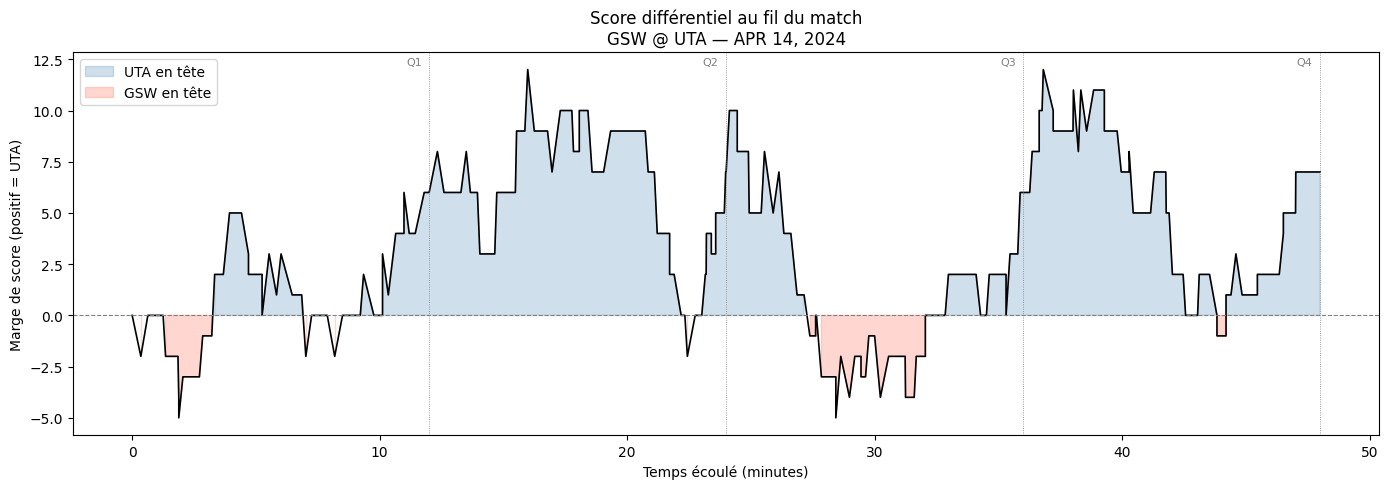

In [15]:
# Récupérer les noms des deux équipes depuis le box score
home_team = df_teams_box.iloc[0]["TEAM_ABBREVIATION"]
away_team = df_teams_box.iloc[1]["TEAM_ABBREVIATION"]

df_plot = df.dropna(subset=["ELAPSED_MINUTES", "SCOREMARGIN_FF"]).copy()

fig, ax = plt.subplots(figsize=(14, 5))

# Zone colorée : vert = home en tête, rouge = visitor en tête
ax.fill_between(
    df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"],
    where=df_plot["SCOREMARGIN_FF"] >= 0, alpha=0.25, color="steelblue", label=f"{home_team} en tête"
)
ax.fill_between(
    df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"],
    where=df_plot["SCOREMARGIN_FF"] < 0,  alpha=0.25, color="tomato",   label=f"{away_team} en tête"
)

ax.plot(df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"], color="black", lw=1.2)
ax.axhline(0, color="gray", lw=0.8, linestyle="--")

# Lignes de fin de quart-temps
for q, t in enumerate([12, 24, 36, 48], start=1):
    ax.axvline(t, color="gray", lw=0.6, linestyle=":")
    ax.text(t - 0.3, ax.get_ylim()[1] * 0.95, f"Q{q}", fontsize=8, color="gray", ha="right")

ax.set_xlabel("Temps écoulé (minutes)")
ax.set_ylabel(f"Marge de score (positif = {home_team})")
ax.set_title(f"Score différentiel au fil du match\n{away_team} @ {home_team} — {df_games['GAME_DATE'].iloc[0]}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 5.3 Détection des "runs" — Séquences de points consécutifs

Un **run** est une série de points marqués consécutivement par la **même équipe** sans que l'adversaire ne marque.  
C'est l'indicateur classique du momentum en NBA (ex. : "un run de 12-0").


In [16]:
# On ne garde que les tirs réussis et les lancers-francs convertis
# V3 : isFieldGoal == 1 + shotResult == 'Made'  OU  actionType == 'Free Throw' + description contient 'PTS'
mask_fg  = (df["isFieldGoal"] == 1) & (df["shotResult"] == "Made")
mask_ft  = (df["actionType"] == "Free Throw") & (df["description"].str.contains("PTS", na=False))
df_score_events = df[mask_fg | mask_ft].copy()

# Identifier qui marque : location == 'h' → home, sinon → visitor
df_score_events["SCORER"] = df_score_events["location"].apply(
    lambda loc: "HOME" if loc == "h" else "VISITOR"
)

# Détection des runs : séquence de scoring consécutive par la même équipe
df_score_events = df_score_events.reset_index(drop=True)
df_score_events["RUN_ID"] = (
    df_score_events["SCORER"] != df_score_events["SCORER"].shift()
).cumsum()

# Variation de score à chaque événement
df_score_events["HOME_DELTA"]    = df_score_events["SCORE_HOME"].diff().fillna(0).clip(lower=0)
df_score_events["VISITOR_DELTA"] = df_score_events["SCORE_VISITOR"].diff().fillna(0).clip(lower=0)

# Agrégation par run
runs = df_score_events.groupby(["RUN_ID", "SCORER"]).agg(
    pts_home    =("HOME_DELTA",     "sum"),
    pts_visitor =("VISITOR_DELTA",  "sum"),
    start_min   =("ELAPSED_MINUTES","first"),
    end_min     =("ELAPSED_MINUTES","last"),
    n_events    =("actionType",     "count"),
).reset_index()

runs["pts"] = runs.apply(
    lambda r: r["pts_home"] if r["SCORER"] == "HOME" else r["pts_visitor"], axis=1
)

# Top 10 des plus grands runs
top_runs = runs.sort_values("pts", ascending=False).head(10)
print("Top 10 des runs du match :")
top_runs[["SCORER", "pts", "start_min", "end_min", "n_events"]].rename(
    columns={"SCORER":"Équipe","pts":"Points marqués","start_min":"Début (min)",
             "end_min":"Fin (min)","n_events":"Nb actions"}
).round(2)


Top 10 des runs du match :


,Équipe,Points marqués,Début (min),Fin (min),Nb actions
51,HOME,12.0,35.47,36.82,6
28,VISITOR,11.0,20.85,22.43,5
3,HOME,10.0,2.05,3.93,4
21,HOME,9.0,14.73,15.98,3
36,VISITOR,8.0,26.33,27.38,3
31,HOME,7.0,23.58,24.13,4
62,VISITOR,7.0,41.78,42.57,3
67,HOME,6.0,45.47,47.02,4
47,HOME,6.0,31.68,32.98,4
29,HOME,6.0,22.75,23.20,3


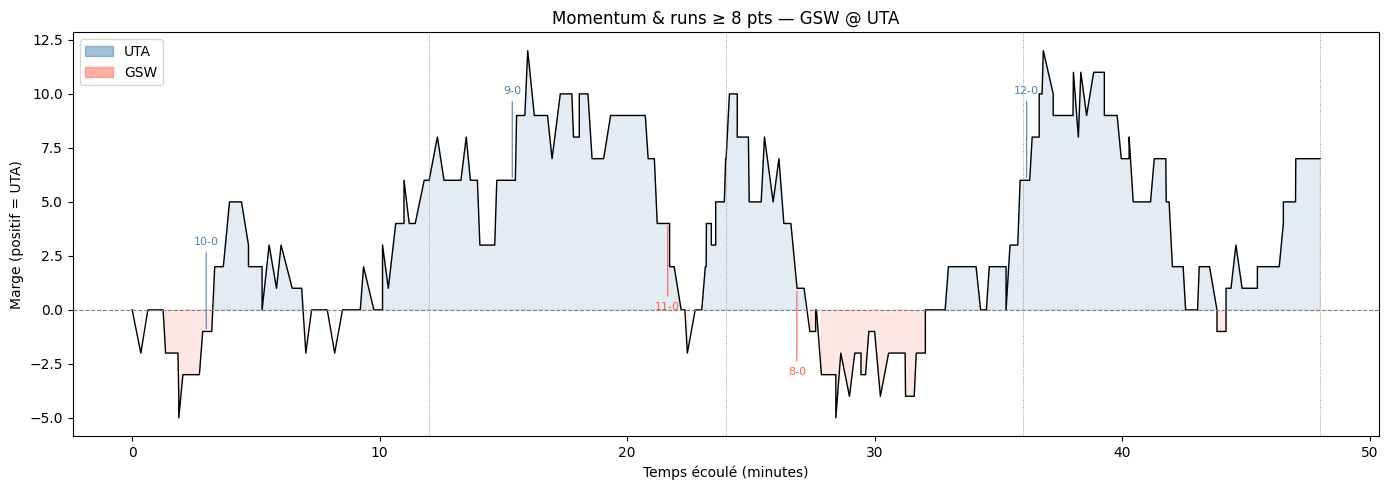

In [17]:
# Visualisation : graphe des runs superposé à la courbe de momentum
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"],
                where=df_plot["SCOREMARGIN_FF"] >= 0, alpha=0.15, color="steelblue")
ax.fill_between(df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"],
                where=df_plot["SCOREMARGIN_FF"] < 0,  alpha=0.15, color="tomato")
ax.plot(df_plot["ELAPSED_MINUTES"], df_plot["SCOREMARGIN_FF"], color="black", lw=1)
ax.axhline(0, color="gray", lw=0.8, linestyle="--")

# Annoter les runs ≥ 8 points
for _, row in runs[runs["pts"] >= 8].iterrows():
    mid   = (row["start_min"] + row["end_min"]) / 2
    yval  = df_plot.loc[
        (df_plot["ELAPSED_MINUTES"] - mid).abs().idxmin(), "SCOREMARGIN_FF"
    ]
    color = "steelblue" if row["SCORER"] == "HOME" else "tomato"
    ax.annotate(
        f"{int(row['pts'])}-0",
        xy=(mid, yval), xytext=(mid, yval + (4 if row["SCORER"] == "HOME" else -4)),
        fontsize=8, color=color, ha="center",
        arrowprops=dict(arrowstyle="-", color=color, lw=0.8),
    )

for q, t in enumerate([12, 24, 36, 48], start=1):
    ax.axvline(t, color="gray", lw=0.6, linestyle=":")

ax.set_xlabel("Temps écoulé (minutes)")
ax.set_ylabel(f"Marge (positif = {home_team})")
ax.set_title(f"Momentum & runs ≥ 8 pts — {away_team} @ {home_team}")
home_patch    = mpatches.Patch(color="steelblue", alpha=0.5, label=f"{home_team}")
visitor_patch = mpatches.Patch(color="tomato",    alpha=0.5, label=f"{away_team}")
ax.legend(handles=[home_patch, visitor_patch], loc="upper left")
plt.tight_layout()
plt.show()


## 6. Analyse sur plusieurs matchs — Momentum agrégé

Pour une étude statistique du momentum, on va collecter le play-by-play de **plusieurs matchs** d'une équipe et calculer le score différentiel moyen par minute de jeu.

> ⚠️ L'API NBA impose un rate-limiting. On respecte un délai `SLEEP` entre chaque requête.


In [18]:
def fetch_pbp_for_games(game_ids: list, sleep: float = 1.0) -> pd.DataFrame:
    """Récupère et concatène le play-by-play enrichi pour une liste de Game IDs (V3)."""
    frames = []
    for i, gid in enumerate(game_ids):
        gid_str = str(gid).zfill(10)
        try:
            pbp_tmp = nba_request_with_retry(
                playbyplayv3.PlayByPlayV3, game_id=gid_str
            ).get_data_frames()[0]

            pbp_tmp["GAME_ID"] = gid
            pbp_tmp["ELAPSED_SECONDS"] = pbp_tmp.apply(
                lambda r: clock_to_elapsed(r["period"], r["clock"]), axis=1
            )
            pbp_tmp["ELAPSED_MINUTES"] = pbp_tmp["ELAPSED_SECONDS"] / 60
            pbp_tmp["SCORE_HOME"]    = pd.to_numeric(pbp_tmp["scoreHome"], errors="coerce").ffill().fillna(0)
            pbp_tmp["SCORE_VISITOR"] = pd.to_numeric(pbp_tmp["scoreAway"], errors="coerce").ffill().fillna(0)
            pbp_tmp["SCOREMARGIN_FF"] = pbp_tmp["SCORE_HOME"] - pbp_tmp["SCORE_VISITOR"]
            frames.append(pbp_tmp)
            print(f"  ✅ [{i+1}/{len(game_ids)}] Game {gid_str} OK ({len(pbp_tmp)} actions)")
        except Exception as e:
            print(f"  ❌ [{i+1}/{len(game_ids)}] Game {gid_str} abandonné : {e}")
        time.sleep(sleep)

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

N_GAMES = 10
game_ids_sample = df_games["Game_ID"].iloc[:N_GAMES].tolist()
print(f"Récupération du PBP de {N_GAMES} matchs des GSW ({SEASON})…")
df_all_pbp = fetch_pbp_for_games(game_ids_sample)
print(f"\n✅ {len(df_all_pbp)} actions collectées sur {N_GAMES} matchs.")


Récupération du PBP de 10 matchs des GSW (2023-24)…
  ✅ [1/10] Game 0022301198 OK (470 actions)
  ✅ [2/10] Game 0022301182 OK (474 actions)
  ✅ [2/10] Game 0022301182 OK (474 actions)
  ✅ [3/10] Game 0022301169 OK (477 actions)
  ✅ [3/10] Game 0022301169 OK (477 actions)
  ✅ [4/10] Game 0022301155 OK (477 actions)
  ✅ [4/10] Game 0022301155 OK (477 actions)
  ✅ [5/10] Game 0022301142 OK (443 actions)
  ✅ [5/10] Game 0022301142 OK (443 actions)
  ✅ [6/10] Game 0022301097 OK (518 actions)
  ✅ [6/10] Game 0022301097 OK (518 actions)
  ✅ [7/10] Game 0022301113 OK (481 actions)
  ✅ [7/10] Game 0022301113 OK (481 actions)
  ✅ [8/10] Game 0022300589 OK (479 actions)
  ✅ [8/10] Game 0022300589 OK (479 actions)
  ✅ [9/10] Game 0022301085 OK (494 actions)
  ✅ [9/10] Game 0022301085 OK (494 actions)
  ✅ [10/10] Game 0022301062 OK (451 actions)
  ✅ [10/10] Game 0022301062 OK (451 actions)

✅ 4764 actions collectées sur 10 matchs.

✅ 4764 actions collectées sur 10 matchs.


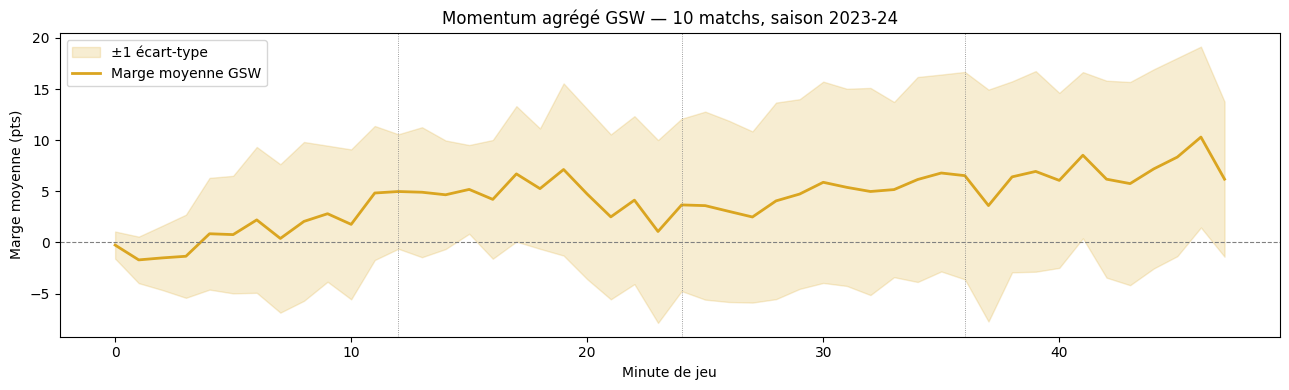

In [19]:
# Score différentiel moyen par tranche de 1 minute (depuis la perspective de GSW)
# On récupère si GSW était HOME ou VISITOR pour chaque match
def get_home_flag(gid, team_id):
    """Renvoie +1 si team_id était HOME, -1 si VISITOR (signe de SCOREMARGIN)."""
    row = df_games[df_games["Game_ID"] == gid]
    if row.empty:
        return 1
    matchup = row["MATCHUP"].values[0]
    # "GSW vs. XXX" → home  /  "GSW @ XXX" → visitor
    return 1 if "vs." in matchup else -1

df_all_pbp["HOME_FLAG"] = df_all_pbp["GAME_ID"].apply(lambda gid: get_home_flag(gid, TEAM_ID))
# Marge vue par GSW
df_all_pbp["MARGIN_GSW"] = df_all_pbp["SCOREMARGIN_FF"] * df_all_pbp["HOME_FLAG"]

# Arrondir au minute inférieure
df_all_pbp["MINUTE_BIN"] = df_all_pbp["ELAPSED_MINUTES"].apply(
    lambda x: int(x) if pd.notna(x) else np.nan
)

agg = (
    df_all_pbp[df_all_pbp["MINUTE_BIN"].between(0, 47)]
    .groupby("MINUTE_BIN")["MARGIN_GSW"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(agg["MINUTE_BIN"],
                agg["mean"] - agg["std"], agg["mean"] + agg["std"],
                alpha=0.2, color="goldenrod", label="±1 écart-type")
ax.plot(agg["MINUTE_BIN"], agg["mean"], color="goldenrod", lw=2, label="Marge moyenne GSW")
ax.axhline(0, color="gray", lw=0.8, linestyle="--")
for q, t in enumerate([12, 24, 36], start=1):
    ax.axvline(t, color="gray", lw=0.6, linestyle=":")

ax.set_xlabel("Minute de jeu")
ax.set_ylabel("Marge moyenne (pts)")
ax.set_title(f"Momentum agrégé GSW — {N_GAMES} matchs, saison {SEASON}")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Référence rapide — Types d'événements (`EVENTMSGTYPE`)

| Code | Événement |
|------|-----------|
| 1 | Tir réussi (field goal made) |
| 2 | Tir raté (field goal missed) |
| 3 | Lancer-franc |
| 4 | Rebond |
| 5 | Perte de balle (turnover) |
| 6 | Faute personnelle |
| 7 | Violation |
| 8 | Substitution (changement de joueur) |
| 9 | Timeout |
| 10 | Jump ball |
| 11 | Éjection |
| 12 | Fin de période |
| 13 | Début de période |

## 8. Pistes pour la suite (mémoire)

- **Fenêtre glissante** : calculer la marge sur une fenêtre de 2-3 minutes pour lisser le momentum
- **Retournements de situation** : détecter les matchs où une équipe remonte un déficit > 15 pts
- **Impact des timeouts** : comparer le margin avant/après chaque timeout
- **Clustering de runs** : regrouper les séquences de runs et identifier des patterns (début de Q3, après timeout…)
- **Corrélation momentum → victoire** : tester si les équipes qui ont le plus de runs de ≥ 8 pts gagnent plus souvent

> 💡 Pour une analyse à grande échelle (toute une saison), pensez à **sauvegarder les DataFrames en Parquet** (`df.to_parquet(...)`) pour éviter de re-requêter l'API à chaque session.
